# Use KG and CLIP to improve recall for BDD100K is predicted by YOLOE

In [79]:
!pip install -q ultralytics

# 1. Installation and Imports

In [80]:
# 1. Installation and Imports
import json, copy
from pathlib import Path
from collections import Counter
from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yaml, numpy as np
from tqdm.auto import tqdm
from ultralytics import YOLO, YOLOE

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch.nn.functional as F
import torchvision

from transformers import CLIPProcessor, CLIPModel

print("All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True


# 2. Configuration

In [88]:
# 2. Configuration
PATH_DATASET = Path("/kaggle/input/datasets/quckhnh123/bdd100k-subset")
PATH_KG = Path("/kaggle/input/datasets/nguyenthien1009/kg-json/KG.json")
IMAGE_DIR = PATH_DATASET / "images"
LABEL_DIR = PATH_DATASET / "labels"
DATA_YAML = PATH_DATASET / "data.yaml"

YOLOE_MODEL_PATH = "yoloe-26m-seg.pt"
YOLOWORLD_MODEL_PATH = "yolov8m-worldv2.pt"

DEVICE = 0
IMGSZ = 640
MAX_IMAGES_TEST = None        

PRED_CONF = 0.01               
EVAL_CONF_THR = 0.25          
IOU_THR = 0.5

USEFUL_RELATIONS = {"isa", "atlocation"}

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("Configuration loaded successfully")
print(f"  Dataset: {PATH_DATASET}")
print(f"  Images: {MAX_IMAGES_TEST or 'All'}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Configuration loaded successfully
  Dataset: /kaggle/input/datasets/quckhnh123/bdd100k-subset
  Images: All


# 3. Dataset Loading and Exploration

In [82]:
# 3. Dataset Loading and Exploration
def load_classes_from_yaml(data_yaml_path):
    with open(data_yaml_path, "r") as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, dict):
        names = [names[k] for k in sorted(names.keys(), key=lambda x: int(x))]
    return [str(x) for x in names]

def load_image_paths(image_dir, max_images=None, seed=42):
    image_dir = Path(image_dir)
    image_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(image_dir.glob(ext))
    return sorted(str(p) for p in image_paths)

def yolo_to_xyxy(xc, yc, bw, bh, w, h):
    x1 = (xc - bw/2) * w
    y1 = (yc - bh/2) * h
    x2 = (xc + bw/2) * w
    y2 = (yc + bh/2) * h
    return [float(x1), float(y1), float(x2), float(y2)]
    
def build_gt(image_paths, labels_dir, target_classes):
    gt = {}
    shapes = {}
    class_counts = Counter()
    for img_path in tqdm(image_paths, desc="Building Ground Truth"):
        try:
            with Image.open(img_path) as img:
                w, h = img.size 
        except Exception:
            continue
            
        shapes[img_path] = (w, h)
        label_path = Path(labels_dir) / (Path(img_path).stem + ".txt")
        boxes = []
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    if cls_id < 0 or cls_id >= len(target_classes):
                        continue
                    xc, yc, bw, bh = map(float, parts[1:5])
                    boxes.append({
                        "class_id": cls_id,
                        "class_name": target_classes[cls_id],
                        "bbox": yolo_to_xyxy(xc, yc, bw, bh, w, h)
                    })
                    class_counts[target_classes[cls_id]] += 1
        gt[img_path] = boxes
    return gt, shapes, class_counts

TARGET_CLASSES = load_classes_from_yaml(DATA_YAML)
image_paths = load_image_paths(IMAGE_DIR, max_images=MAX_IMAGES_TEST)
GT, IMAGE_SHAPES, CLASS_COUNTS = build_gt(image_paths, LABEL_DIR, TARGET_CLASSES)

print(f"\n Dataset Statistics:")
print(f"  - Total images: {len(image_paths)}")
print(f"  - Total annotations: {sum(len(v) for v in GT.values()):,}")
print(f"  - Classes: {len(TARGET_CLASSES)}")
print(f"  - Average objects per image: {sum(len(v) for v in GT.values())/len(GT):.2f}")

Building Ground Truth:   0%|          | 0/10000 [00:00<?, ?it/s]


 Dataset Statistics:
  - Total images: 10000
  - Total annotations: 190,888
  - Classes: 10
  - Average objects per image: 19.09


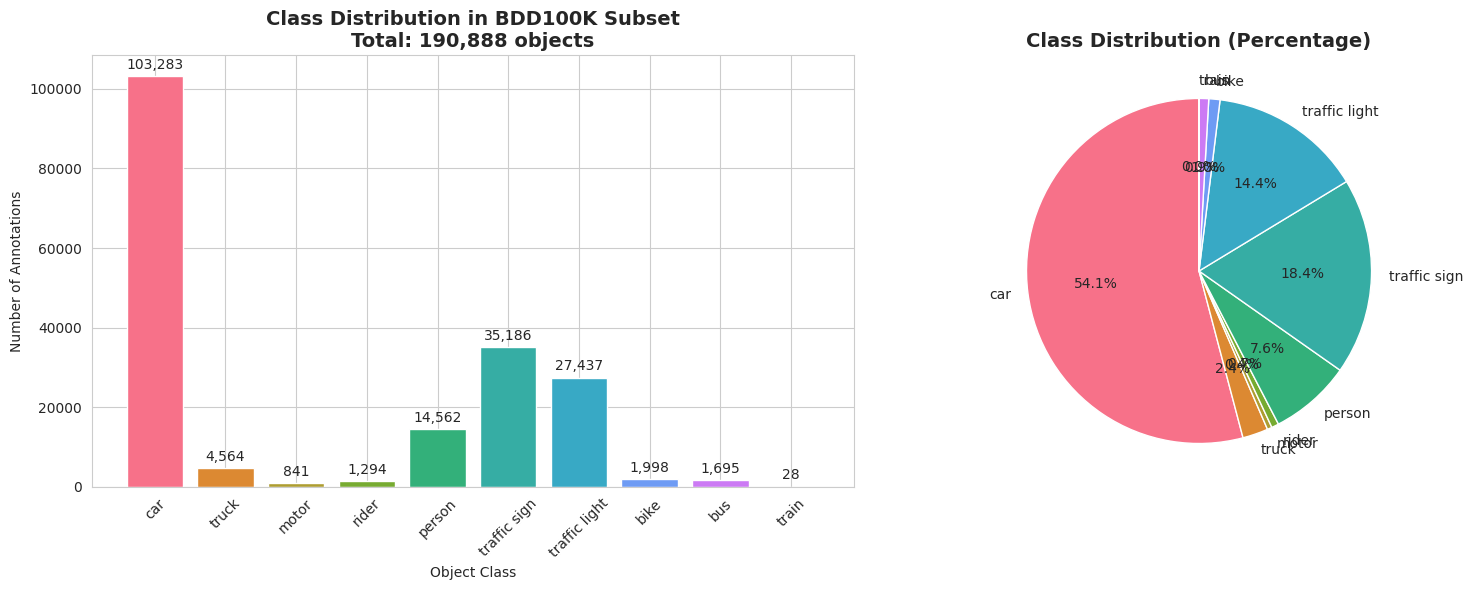


 Class Imbalance Analysis:
  car            : 103,283 ( 54.1%)
  traffic sign   : 35,186 ( 18.4%)
  traffic light  : 27,437 ( 14.4%)
  person         : 14,562 (  7.6%)
  truck          :  4,564 (  2.4%)
  bike           :  1,998 (  1.0%)
  bus            :  1,695 (  0.9%)
  rider          :  1,294 (  0.7%)
  motor          :    841 (  0.4%)
  train          :     28 (  0.0%)


In [83]:
# Exploratory Data Analysis - Visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = list(CLASS_COUNTS.keys())
counts = list(CLASS_COUNTS.values())
colors = sns.color_palette("husl", len(classes))

bars = axes[0].bar(classes, counts, color=colors)
axes[0].set_title(f"Class Distribution in BDD100K Subset\nTotal: {sum(counts):,} objects", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Object Class")
axes[0].set_ylabel("Number of Annotations")
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f'{count:,}', ha='center', va='bottom', fontsize=10)

axes[1].pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title("Class Distribution (Percentage)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Class Imbalance Analysis:")
for cls, count in sorted(CLASS_COUNTS.items(), key=lambda x: x[1], reverse=True):
    pct = (count / sum(CLASS_COUNTS.values())) * 100
    print(f"  {cls:15s}: {count:6,d} ({pct:5.1f}%)")

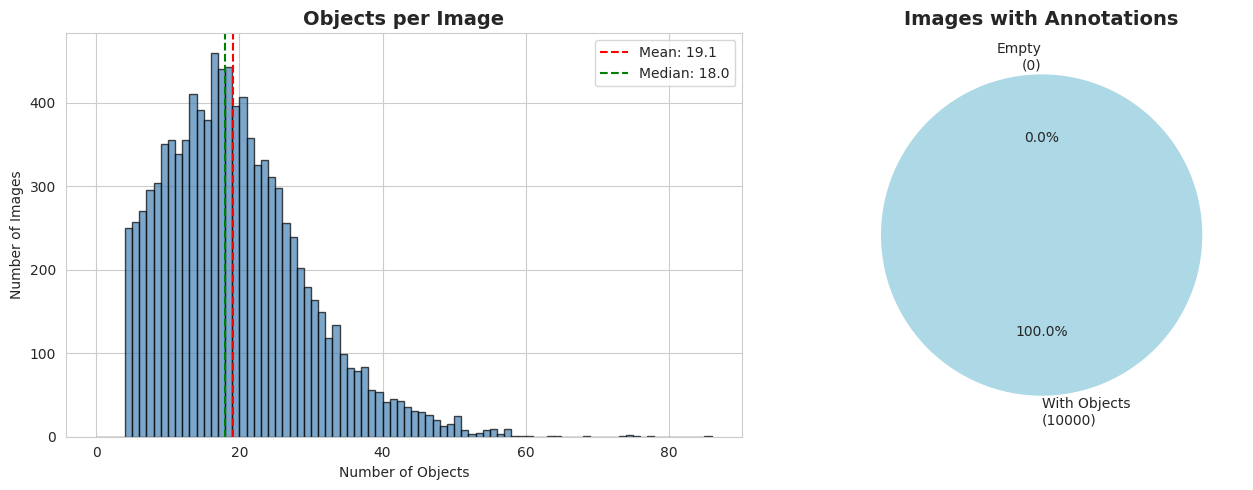


 Image Statistics:
  Images with annotations: 10,000 (100.0%)
  Images without annotations: 0 (0.0%)
  Mean objects per image: 19.09
  Max objects per image: 85


In [84]:
# Image-level statistics
images_with_boxes = sum(1 for boxes in GT.values() if len(boxes) > 0)
objects_per_image = [len(boxes) for boxes in GT.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(objects_per_image, bins=range(0, max(objects_per_image)+2, 1), 
             color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title("Objects per Image", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Objects")
axes[0].set_ylabel("Number of Images")
axes[0].axvline(np.mean(objects_per_image), color='red', linestyle='--', label=f'Mean: {np.mean(objects_per_image):.1f}')
axes[0].axvline(np.median(objects_per_image), color='green', linestyle='--', label=f'Median: {np.median(objects_per_image):.1f}')
axes[0].legend()

empty_images = sum(1 for n in objects_per_image if n == 0)
axes[1].pie([empty_images, len(objects_per_image)-empty_images], 
            labels=[f'Empty\n({empty_images})', f'With Objects\n({len(objects_per_image)-empty_images})'],
            autopct='%1.1f%%', colors=['lightcoral', 'lightblue'], startangle=90)
axes[1].set_title("Images with Annotations", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("image_statistics.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Image Statistics:")
print(f"  Images with annotations: {images_with_boxes:,} ({images_with_boxes/len(GT)*100:.1f}%)")
print(f"  Images without annotations: {empty_images:,} ({empty_images/len(GT)*100:.1f}%)")
print(f"  Mean objects per image: {np.mean(objects_per_image):.2f}")
print(f"  Max objects per image: {max(objects_per_image)}")

# 4. Load ConceptNet + build concept sets

In [89]:
# 4. Load ConceptNet + build concept sets
def normalize_name(x):
    return str(x).lower().replace("_", " ").replace("-", " ").strip()

def clean_concept_uri(x):
    x = str(x).lower().strip()
    for w in ["a ", "an ", "the "]:
        x = x.replace(w, "")
    return normalize_name(x)

def clean_relation(x):
    m = {"AtLocation":"atlocation", "IsA":"isa"}
    return m.get(x, x.lower().strip())

def is_noisy_concept(text, max_words=5):
    t = normalize_name(text)
    return len(t)<=1 or '/' in t or len(t.split())>max_words

def load_conceptnet_json(path):
    with open(path, "r", encoding="utf-8") as f:
        kg = json.load(f)
    graph = {}
    total_triples = 0
    for cls, relations in kg.items():
        cls = normalize_name(cls)
        graph[cls] = {}
        for relation, objects in relations.items():
            relation = clean_relation(relation)
            if relation not in USEFUL_RELATIONS:
                continue
            concepts = { clean_concept_uri(obj) for obj in objects if not is_noisy_concept(obj) }
            graph[cls][relation] = concepts
            total_triples += len(concepts)

    print(f"Loaded {total_triples} triples from KG JSON")
    return graph

def build_class_concepts(target_classes, graph, top_k=30):
    class_concepts = {}

    for cls in target_classes:
        cls_clean = normalize_name(cls)
        relations = graph.get(cls_clean, {})

        class_concepts[cls] = {}

        for relation, concepts in relations.items():
            class_concepts[cls][relation] = set(list(concepts)[:top_k])
            
    return class_concepts

conceptnet_df = load_conceptnet_json(PATH_KG)
CLASS_CONCEPTS = build_class_concepts(TARGET_CLASSES, conceptnet_df, top_k=30)

print(f"\n Knowledge Graph Statistics:")
print(f"  Total triples: {len(conceptnet_df)}")
print(f"  Classes with concepts: {sum(1 for c in CLASS_CONCEPTS if CLASS_CONCEPTS[c])}")
for cls, concepts in CLASS_CONCEPTS.items():
    total_concepts_for_class = sum(len(concept_set) for concept_set in concepts.values())
    print(f"  {cls:15s}: {total_concepts_for_class} concepts")

Loaded 155 triples from KG JSON

 Knowledge Graph Statistics:
  Total triples: 24
  Classes with concepts: 10
  person         : 8 concepts
  rider          : 7 concepts
  car            : 13 concepts
  bus            : 9 concepts
  truck          : 7 concepts
  bike           : 5 concepts
  motor          : 4 concepts
  traffic light  : 5 concepts
  traffic sign   : 5 concepts
  train          : 3 concepts


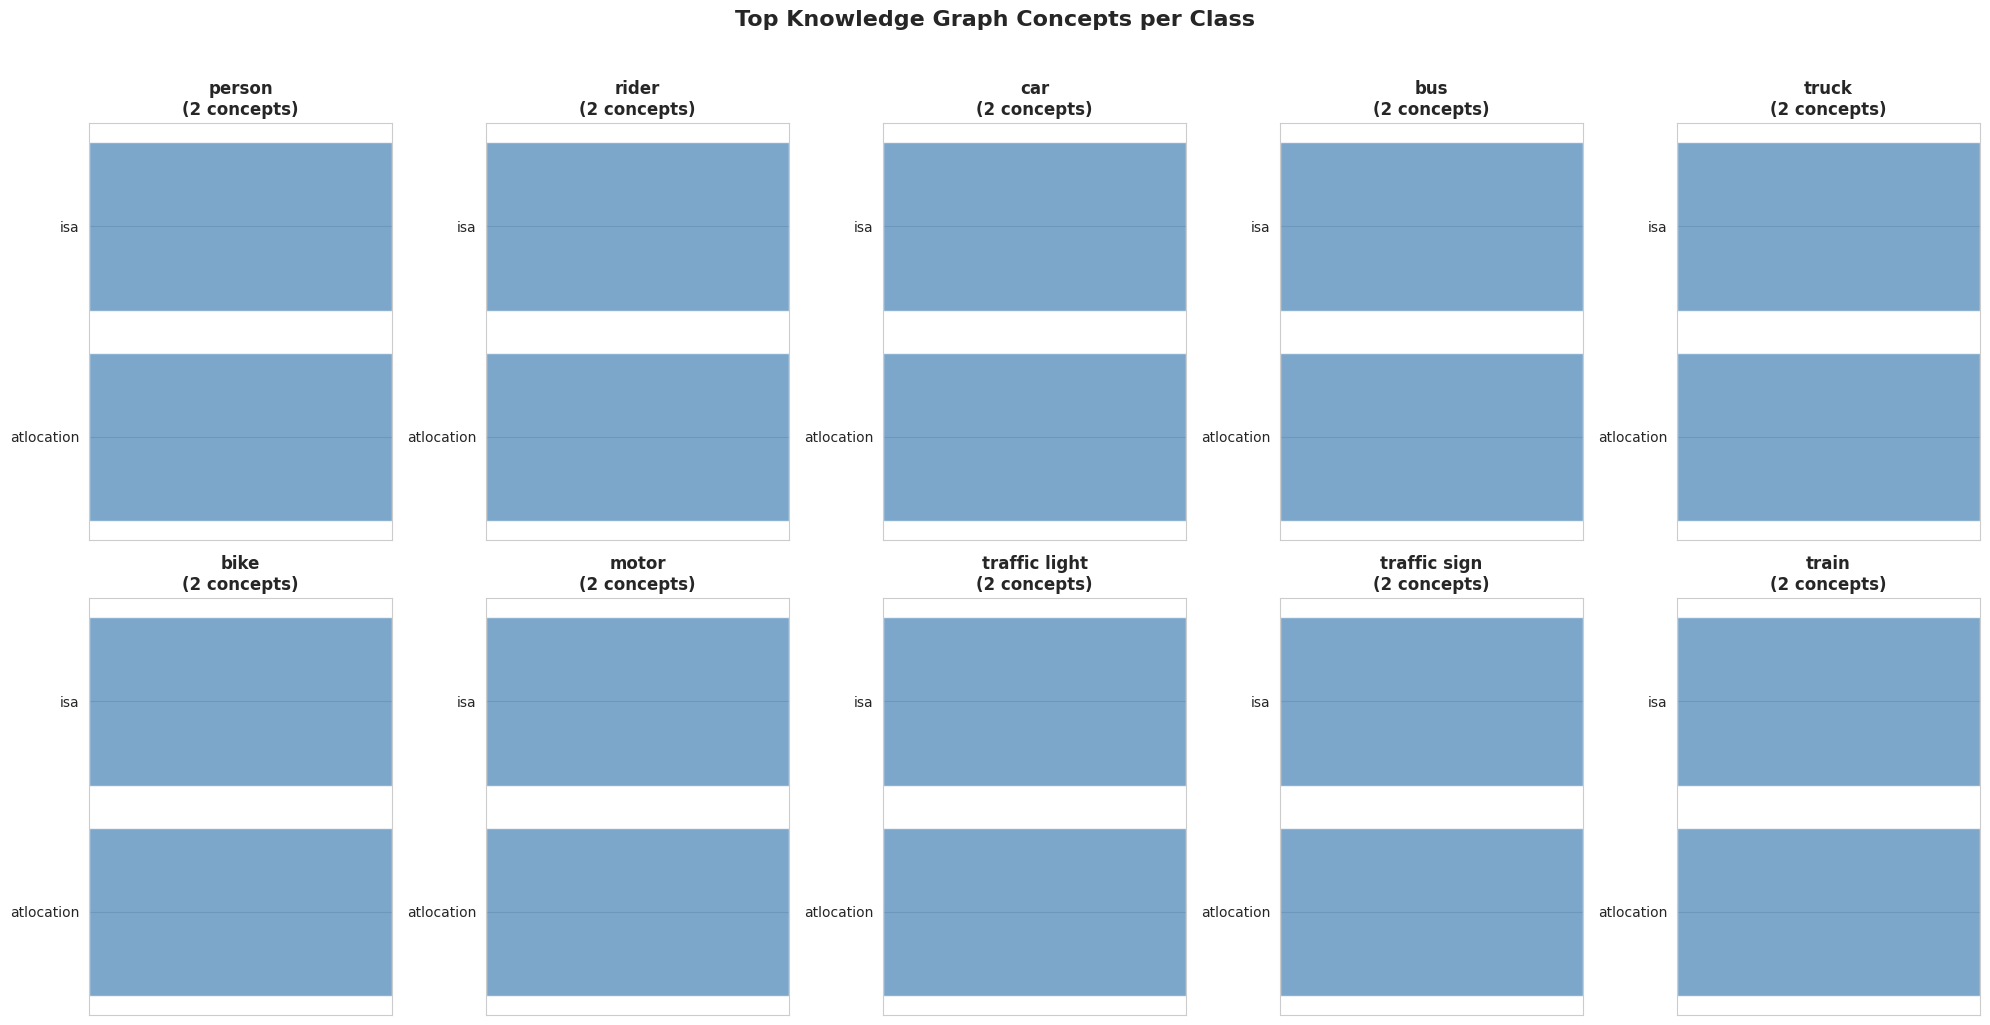


 Concept Overlap:
  Total unique concepts: 2
  Average concepts per class: 2.0


In [90]:
# Visualize Knowledge Graph Concepts
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (cls, concepts) in enumerate(CLASS_CONCEPTS.items()):
    concept_list = list(concepts)[:10]
    axes[idx].barh(concept_list, [1]*len(concept_list), color='steelblue', alpha=0.7)
    axes[idx].set_title(f"{cls}\n({len(concepts)} concepts)", fontsize=12, fontweight='bold')
    axes[idx].set_xlim(0, 1)
    axes[idx].set_xticks([])
    axes[idx].set_xlabel("")

plt.suptitle("Top Knowledge Graph Concepts per Class", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("kg_concepts.png", dpi=300, bbox_inches='tight')
plt.show()

all_concepts = set()
for concepts in CLASS_CONCEPTS.values():
    all_concepts.update(concepts)

print(f"\n Concept Overlap:")
print(f"  Total unique concepts: {len(all_concepts)}")
print(f"  Average concepts per class: {np.mean([len(c) for c in CLASS_CONCEPTS.values()]):.1f}")

# 5. Evaluation Functions

In [91]:
# 5. Evaluation Functions
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-9
    return inter / union

def compute_map_torchmetrics(preds_dict, gt_dict):
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    preds = []
    targets = []
    all_imgs = sorted(gt_dict.keys())

    for img_path in all_imgs:
        pred_boxes, pred_scores, pred_labels = [], [], []
        for p in preds_dict.get(img_path, []):
            pred_boxes.append(p["bbox"])
            pred_scores.append(p["conf"])
            pred_labels.append(p["class_id"])

        gt_boxes, gt_labels = [], []
        for g in gt_dict.get(img_path, []):
            gt_boxes.append(g["bbox"])
            gt_labels.append(g["class_id"])

        preds.append({
            "boxes": torch.tensor(pred_boxes, dtype=torch.float32).reshape(-1,4),
            "scores": torch.tensor(pred_scores, dtype=torch.float32),
            "labels": torch.tensor(pred_labels, dtype=torch.int64)
        })
        targets.append({
            "boxes": torch.tensor(gt_boxes, dtype=torch.float32).reshape(-1,4),
            "labels": torch.tensor(gt_labels, dtype=torch.int64)
        })

    metric.update(preds, targets)
    result = metric.compute()
    return {"map50": float(result["map_50"]), "map50_95": float(result["map"])}

def evaluate(preds_dict, gt_dict, target_classes, conf_thr=0.25, iou_thr=0.5):
    per_class = {c: {"tp":0,"fp":0,"fn":0} for c in target_classes}
    for img_path, gt_boxes in gt_dict.items():
        preds = [p for p in preds_dict.get(img_path, []) if p["conf"] >= conf_thr]
        preds = sorted(preds, key=lambda x: x["conf"], reverse=True)
        matched = set()
        for p in preds:
            best_iou, best_idx = 0.0, -1
            for i,g in enumerate(gt_boxes):
                if i in matched or p["class_id"] != g["class_id"]:
                    continue
                iou = compute_iou(p["bbox"], g["bbox"])
                if iou > best_iou:
                    best_iou, best_idx = iou, i
            if best_iou >= iou_thr and best_idx >= 0:
                per_class[p["class_name"]]["tp"] += 1
                matched.add(best_idx)
            else:
                per_class[p["class_name"]]["fp"] += 1
        for i,g in enumerate(gt_boxes):
            if i not in matched:
                per_class[g["class_name"]]["fn"] += 1

    rows, total_tp, total_fp, total_fn = [], 0, 0, 0
    for cls in target_classes:
        tp, fp, fn = per_class[cls]["tp"], per_class[cls]["fp"], per_class[cls]["fn"]
        p = tp/(tp+fp+1e-9)
        r = tp/(tp+fn+1e-9)
        f = 2*p*r/(p+r+1e-9)
        rows.append({"class_name":cls, "tp":tp, "fp":fp, "fn":fn, "precision":p, "recall":r, "f1":f})
        total_tp += tp; total_fp += fp; total_fn += fn

    p_all = total_tp/(total_tp+total_fp+1e-9)
    r_all = total_tp/(total_tp+total_fn+1e-9)
    f_all = 2*p_all*r_all/(p_all+r_all+1e-9)
    map_result = compute_map_torchmetrics(preds_dict, gt_dict)
    
    summary = {
        "precision": p_all, "recall": r_all, "f1": f_all,
        "map50": map_result["map50"], "map50_95": map_result["map50_95"],
        "total_tp": total_tp, "total_fp": total_fp, "total_fn": total_fn
    }
    return summary, pd.DataFrame(rows)

# 6. Prediction Utilities

In [92]:
# 6. Prediction Utilities
def load_yoloe_with_prompts(path, target_classes):
    model = YOLOE(path)
    prompts = [c.replace("_", " ") for c in target_classes]
    model.set_classes(prompts)
    return model

def load_yoloworld(path, target_classes):
    model = YOLO(path)
    prompts = [c.replace("_", " ") for c in target_classes]
    model.set_classes(prompts)
    return model

def predict_model(model, image_paths, target_classes, conf=0.03, imgsz=640, device=0, an=True):
    all_preds = {} 
    for img in tqdm(image_paths, desc="Predicting"):
        results = model.predict(source=img, conf=conf, imgsz=imgsz, device=device, verbose=False, agnostic_nms=an)
        preds = []
        for r in results:
            if r.boxes is None:
                continue
            boxes = r.boxes.xyxy.cpu().numpy()
            scores = r.boxes.conf.cpu().numpy()
            clses = r.boxes.cls.cpu().numpy().astype(int)
            for box, score, cls_id in zip(boxes, scores, clses):
                if 0 <= cls_id < len(target_classes):
                    preds.append({
                        "image": img,
                        "class_id": int(cls_id),
                        "class_name": target_classes[cls_id],
                        "conf": float(score),
                        "bbox": [float(x) for x in box]
                    })
        all_preds[img] = preds
    return all_preds

# 7. Baseline: YOLOE

In [93]:
# 7. Baseline: YOLOE
model_yoloe = load_yoloe_with_prompts(YOLOE_MODEL_PATH, TARGET_CLASSES)

pred_yoloe = predict_model(model_yoloe, image_paths, TARGET_CLASSES, conf=PRED_CONF, imgsz=IMGSZ, device=DEVICE, an=False)

summary_yoloe, per_class_yoloe = evaluate(pred_yoloe, GT, TARGET_CLASSES, conf_thr=EVAL_CONF_THR, iou_thr=IOU_THR)
print(summary_yoloe)

Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


{'precision': 0.8017317126748041, 'recall': 0.22943820460165004, 'f1': 0.3567751181798867, 'map50': 0.30336564779281616, 'map50_95': 0.16966204345226288, 'total_tp': 43797, 'total_fp': 10831, 'total_fn': 147091}


# 8. Proposed Method: Knowledge Graph + CLIP

In [94]:
# 8. Proposed Method: KG + CLIP Optimization
def build_global_prompts(class_concepts):
    prompt_map = {}
    all_prompts = []

    for cls, relations in class_concepts.items():
        prompts = []
        
        for concept in relations.get("isa", set()):
            prompt = f"a photo of {concept}"
            prompts.append(prompt)
            all_prompts.append(prompt)
            
        for concept in relations.get("atlocation", set()):
            prompt = f"a photo of {cls} in {concept}"
            prompts.append(prompt)
            all_prompts.append(prompt)
            
        prompt_map[cls] = prompts

    return prompt_map, all_prompts

def clip_kg_optimize(all_preds,class_concepts,low_conf_thr=0.45,alpha=0.5):
    prompt_map, all_prompts = build_global_prompts(class_concepts)
    unique_prompts = list(dict.fromkeys(all_prompts))
    
    text_inputs = clip_processor(
        text=unique_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)
    with torch.no_grad():
        text_outputs = clip_model.get_text_features(**text_inputs)

        if hasattr(text_outputs, 'pooler_output'):
            text_features = text_outputs.pooler_output
        else:
            text_features = text_outputs

        text_features = F.normalize(text_features, dim=-1)

    new_preds = {}

    for img_path, preds in tqdm(all_preds.items(), desc="CLIP Processing"):
        local_preds = copy.deepcopy(preds)
        image = Image.open(img_path).convert("RGB")

        image_inputs = clip_processor(
            images=image,
            return_tensors="pt",
        ).to(DEVICE)

        with torch.no_grad():
            image_outputs = clip_model.get_image_features(**image_inputs)
            
            if hasattr(image_outputs, 'pooler_output'):
                image_features = image_outputs.pooler_output
            else:
                image_features = image_outputs
            image_features = F.normalize(image_features, dim=-1)

            similarity = image_features @ text_features.T 

            probs = similarity.squeeze(0).cpu().numpy()

        prompt_scores = dict(zip(unique_prompts, probs))

        class_prior = {}
        for cls, prompts in prompt_map.items():
            if len(prompts) == 0:
                class_prior[cls] = 0.0
                continue
            scores = [prompt_scores.get(p, 0.0) for p in prompts]
            class_prior[cls] = sum(scores) / len(prompts)

        values = np.array(list(class_prior.values()))
        if len(values) > 1 and values.max() > values.min() + 1e-8:
            min_v = values.min()
            max_v = values.max()
            for cls in class_prior:
                class _prior[cls] = (class_prior[cls] - min_v) / (max_v - min_v + 1e-8)

        for p in local_preds:
            cls = p["class_name"]
            conf = float(p["conf"])
            prior = class_prior.get(cls, 0.0)

            p["clip_prior"] = prior
            p["fused"] = False

            if conf < low_conf_thr:
                fused = (conf ** alpha) * (prior ** (1 - alpha))

                if fused > conf:
                    p["conf"] = fused
                    p["fused"] = True

        new_preds[img_path] = local_preds

    return new_preds

In [95]:
def apply_nms(preds_dict, iou_thr=0.7):
    new_preds = {}

    for img_path, preds in preds_dict.items():

        if len(preds) == 0:
            new_preds[img_path] = []
            continue

        kept_preds = []

        class_ids = sorted(set(p["class_id"] for p in preds))

        for cls in class_ids:

            cls_preds = [p for p in preds if p["class_id"] == cls]

            boxes = torch.tensor(
                [p["bbox"] for p in cls_preds],
                dtype=torch.float32
            )

            scores = torch.tensor(
                [p["conf"] for p in cls_preds],
                dtype=torch.float32
            )

            keep = torchvision.ops.nms(
                boxes,
                scores,
                iou_thr
            )

            for idx in keep.tolist():
                kept_preds.append(cls_preds[idx])

        new_preds[img_path] = kept_preds

    return new_preds

## 9. Fine-tune Hyperparameters

**Bước 1:** Grid search `alpha` ∈ [0.20, 0.85], cố định `low_conf_thr=0.45`

**Bước 2:** Grid search `low_conf_thr` ∈ [0.20, 0.65] với `best_alpha` từ bước 1

Tuning alpha: [np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85)]
Fixed low_conf_thr=0.45


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

alpha=0.20 | P=0.3415 | R=0.5377 | F1=0.4177 | mAP50=0.2724 | mAP50-95=0.1474


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

alpha=0.25 | P=0.3645 | R=0.5200 | F1=0.4286 | mAP50=0.2852 | mAP50-95=0.1564


...

alpha=0.75 | P=0.7731 | R=0.2694 | F1=0.3996 | mAP50=0.3099 | mAP50-95=0.1713


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

alpha=0.80 | P=0.7842 | R=0.2597 | F1=0.3902 | mAP50=0.3099 | mAP50-95=0.1713


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

alpha=0.85 | P=0.7934 | R=0.2509 | F1=0.3813 | mAP50=0.3099 | mAP50-95=0.1713
Best alpha = 0.75


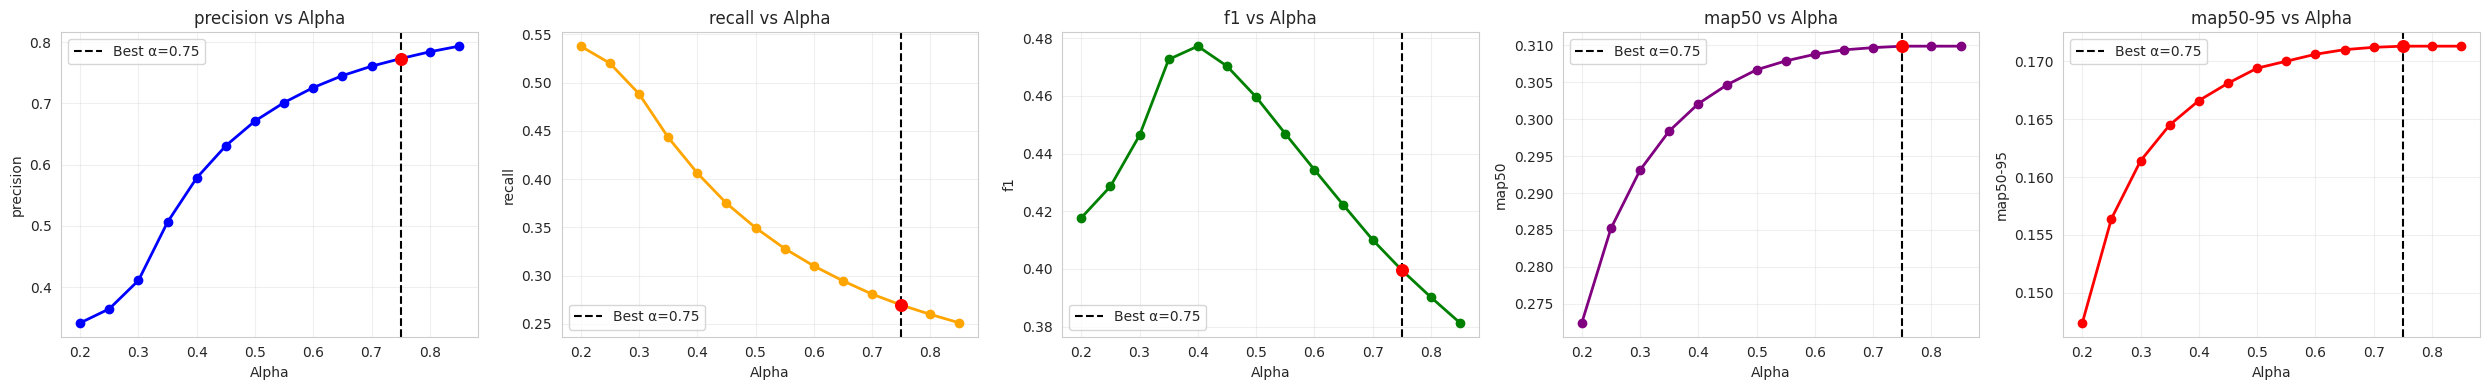

 alpha  precision  recall     f1  map50  map50-95  total_tp  total_fp  total_fn
  0.20     0.3415  0.5377 0.4177 0.2724    0.1474    102643    197963     88245
  0.25     0.3645  0.5200 0.4286 0.2852    0.1564     99270    173067     91618
  0.30     0.4109  0.4883 0.4463 0.2931    0.1614     93210    133632     97678
  0.35     0.5063  0.4432 0.4726 0.2984    0.1645     84601     82506    106287
  0.40     0.5784  0.4062 0.4772 0.3021    0.1666     77538     56518    113350
  0.45     0.6309  0.3749 0.4703 0.3047    0.1681     71571     41875    119317
  0.50     0.6712  0.3495 0.4596 0.3067    0.1694     66710     32674    124178
  0.55     0.7014  0.3279 0.4469 0.3079    0.1700     62590     26643    128298
  0.60     0.7258  0.3099 0.4344 0.3088    0.1706     59160     22351    131728
  0.65     0.7453  0.2945 0.4221 0.3094    0.1710     56207     19204    134681
  0.70     0.7607  0.2807 0.4101 0.3097    0.1712     53578     16855    137310
  0.75     0.7731  0.2694 0.3996 0.3099 

CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


KeyboardInterrupt: 

In [97]:
# Fine-tune alpha 
# =========================
# Tune alpha
# =========================
def tune_alpha(
    pred_yoloe,
    class_concepts,
    gt_dict,
    target_classes,
    alpha_list=None,
    low_conf_thr=0.45,
    eval_conf_thr=0.25,
    iou_thr=0.50,
    rerank_fn=None
):

    if alpha_list is None:
        alpha_list = [round(a, 2) for a in np.arange(0.20, 0.90, 0.05)]

    if rerank_fn is None:
        rerank_fn = clip_kg_optimize

    print(f"Tuning alpha: {alpha_list}")
    print(f"Fixed low_conf_thr={low_conf_thr}")
    print("=" * 70)

    rows = []

    for alpha in alpha_list:

        preds_reranked = rerank_fn(
            copy.deepcopy(pred_yoloe),
            class_concepts,
            low_conf_thr=low_conf_thr,
            alpha=alpha
        )

        preds_reranked_nms = apply_nms(
            preds_reranked,
            iou_thr=0.7
        )

        s, _ = evaluate(
            preds_reranked_nms,
            gt_dict,
            target_classes,
            conf_thr=eval_conf_thr,
            iou_thr=iou_thr
        )

        rows.append({
            "alpha": alpha,
            "precision": round(s["precision"], 4),
            "recall": round(s["recall"], 4),
            "f1": round(s["f1"], 4),
            "map50": round(s["map50"], 4),
            "map50-95": round(s["map50_95"], 4),
            "total_tp": s["total_tp"],
            "total_fp": s["total_fp"],
            "total_fn": s["total_fn"],
        })

        print(
            f"alpha={alpha:.2f} | "
            f"P={s['precision']:.4f} | "
            f"R={s['recall']:.4f} | "
            f"F1={s['f1']:.4f} | "
            f"mAP50={s['map50']:.4f} | "
            f"mAP50-95={s['map50_95']:.4f}"
        )

    df_alpha = pd.DataFrame(rows)

    best_alpha = df_alpha.loc[
        df_alpha["map50-95"].idxmax(),
        "alpha"
    ]

    print("=" * 70)
    print(f"Best alpha = {best_alpha}")

    metrics = [
        "precision",
        "recall",
        "f1",
        "map50",
        "map50-95"
    ]

    colors = [
        "blue",
        "orange",
        "green",
        "purple",
        "red"
    ]

    fig, axes = plt.subplots(1, 5, figsize=(25,4))

    for ax, metric, color in zip(axes, metrics, colors):

        ax.plot(
            df_alpha["alpha"],
            df_alpha[metric],
            marker="o",
            linewidth=2,
            color=color
        )

        ax.axvline(
            best_alpha,
            color="black",
            linestyle="--",
            label=f"Best α={best_alpha}"
        )

        y = df_alpha.loc[
            df_alpha["alpha"] == best_alpha,
            metric
        ].values[0]

        ax.scatter(
            best_alpha,
            y,
            color="red",
            s=70,
            zorder=5
        )

        ax.set_xlabel("Alpha")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs Alpha")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    return df_alpha, best_alpha


# =========================
# Tune low_conf_thr
# =========================
def tune_low_conf_thr(
    pred_yoloe,
    class_concepts,
    gt_dict,
    target_classes,
    best_alpha,
    thr_list=None,
    eval_conf_thr=0.25,
    iou_thr=0.50,
    rerank_fn=None
):

    if thr_list is None:
        thr_list = [round(t,2) for t in np.arange(0.20,0.70,0.05)]

    if rerank_fn is None:
        rerank_fn = clip_kg_optimize

    print(f"Tuning low_conf_thr: {thr_list}")
    print(f"Fixed alpha={best_alpha}")
    print("=" * 70)

    rows = []

    for thr in thr_list:

        preds_reranked = rerank_fn(
            copy.deepcopy(pred_yoloe),
            class_concepts,
            low_conf_thr=thr,
            alpha=best_alpha
        )

        preds_reranked_nms = apply_nms(
            preds_reranked,
            iou_thr=0.7
        )

        s, _ = evaluate(
            preds_reranked_nms,
            gt_dict,
            target_classes,
            conf_thr=eval_conf_thr,
            iou_thr=iou_thr
        )

        rows.append({
            "low_conf_thr": thr,
            "precision": round(s["precision"],4),
            "recall": round(s["recall"],4),
            "f1": round(s["f1"],4),
            "map50": round(s["map50"],4),
            "map50-95": round(s["map50_95"],4),
            "total_tp": s["total_tp"],
            "total_fp": s["total_fp"],
            "total_fn": s["total_fn"]
        })

        print(
            f"thr={thr:.2f} | "
            f"P={s['precision']:.4f} | "
            f"R={s['recall']:.4f} | "
            f"F1={s['f1']:.4f} | "
            f"mAP50={s['map50']:.4f} | "
            f"mAP50-95={s['map50_95']:.4f}"
        )

    df_thr = pd.DataFrame(rows)

    best_thr = df_thr.loc[
        df_thr["map50-95"].idxmax(),
        "low_conf_thr"
    ]

    print("=" * 70)
    print(f"Best low_conf_thr = {best_thr}")

    metrics = [
        "precision",
        "recall",
        "f1",
        "map50",
        "map50-95"
    ]

    colors = [
        "blue",
        "orange",
        "green",
        "purple",
        "red"
    ]

    fig, axes = plt.subplots(1,5,figsize=(25,4))

    for ax, metric, color in zip(axes, metrics, colors):

        ax.plot(
            df_thr["low_conf_thr"],
            df_thr[metric],
            marker="o",
            linewidth=2,
            color=color
        )

        ax.axvline(
            best_thr,
            color="black",
            linestyle="--",
            label=f"Best={best_thr}"
        )

        y = df_thr.loc[
            df_thr["low_conf_thr"] == best_thr,
            metric
        ].values[0]

        ax.scatter(
            best_thr,
            y,
            color="red",
            s=70,
            zorder=5
        )

        ax.set_xlabel("Low Confidence Threshold")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs Threshold")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    return df_thr, best_thr

# Bước 1: Tune alpha (cố định low_conf_thr=0.45)
df_alpha, best_alpha = tune_alpha(
    pred_yoloe     = pred_yoloe,
    class_concepts = CLASS_CONCEPTS,
    gt_dict        = GT,
    target_classes = TARGET_CLASSES,
    alpha_list     = [round(a, 2) for a in np.arange(0.20, 0.90, 0.05)],
    low_conf_thr   = 0.45,
    eval_conf_thr  = EVAL_CONF_THR,
    iou_thr        = IOU_THR,
    rerank_fn      = clip_kg_optimize
)

print(df_alpha.to_string(index=False))





Tuning low_conf_thr: [np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35)]
Fixed alpha=0.75


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

thr=0.20 | P=0.7937 | R=0.2451 | F1=0.3745 | mAP50=0.3096 | mAP50-95=0.1712


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

thr=0.25 | P=0.7731 | R=0.2694 | F1=0.3996 | mAP50=0.3100 | mAP50-95=0.1713


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

thr=0.30 | P=0.7730 | R=0.2694 | F1=0.3996 | mAP50=0.3101 | mAP50-95=0.1715


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

thr=0.35 | P=0.7731 | R=0.2694 | F1=0.3996 | mAP50=0.3101 | mAP50-95=0.1714
Best low_conf_thr = 0.3


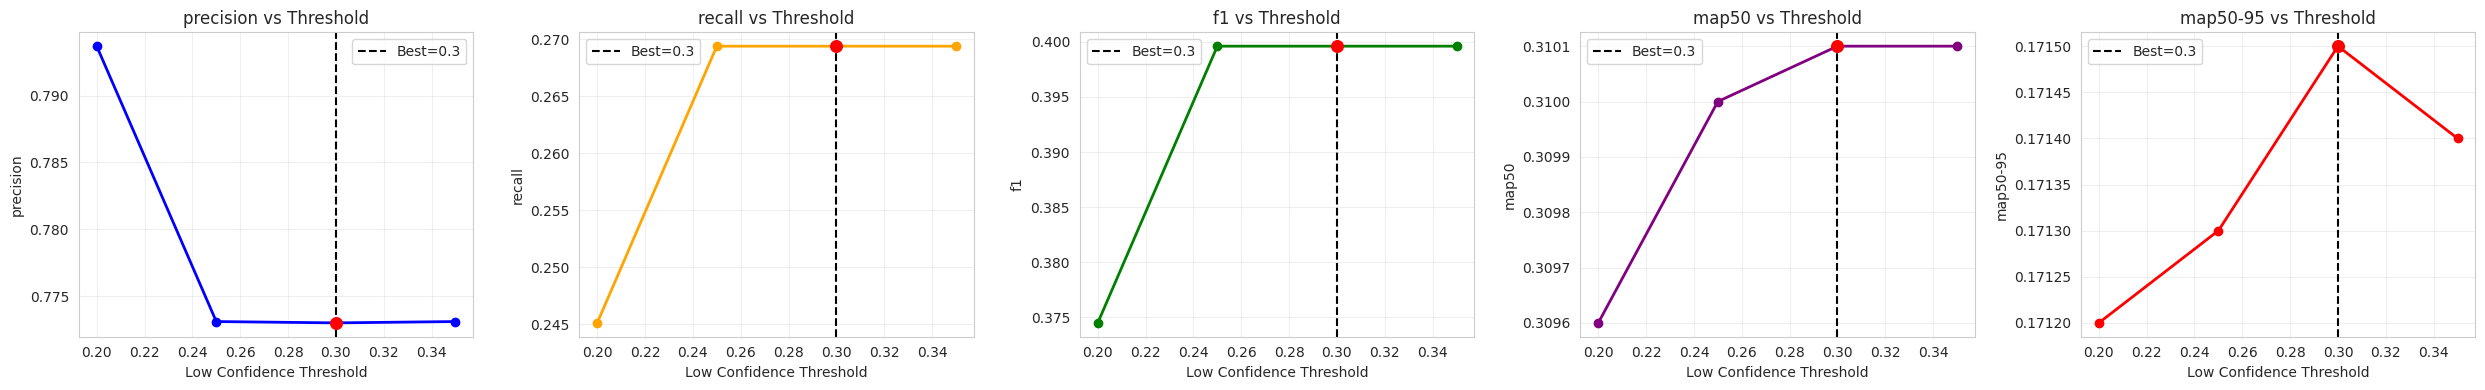

 low_conf_thr  precision  recall     f1  map50  map50-95  total_tp  total_fp  total_fn
         0.20     0.7937  0.2451 0.3745 0.3096    0.1712     46788     12160    144100
         0.25     0.7731  0.2694 0.3996 0.3100    0.1713     51434     15098    139454
         0.30     0.7730  0.2694 0.3996 0.3101    0.1715     51432     15100    139456
         0.35     0.7731  0.2694 0.3996 0.3101    0.1714     51434     15099    139454


In [98]:
# Bước 2: Tune low_conf_thr với best_alpha từ bước 1
df_thr, best_thr = tune_low_conf_thr(
    pred_yoloe     = pred_yoloe,
    class_concepts = CLASS_CONCEPTS,
    gt_dict        = GT,
    target_classes = TARGET_CLASSES,
    best_alpha     = best_alpha,
    thr_list       = [round(t, 2) for t in np.arange(0.20, 0.40, 0.05)],
    eval_conf_thr  = EVAL_CONF_THR,
    iou_thr        = IOU_THR,
    rerank_fn      = clip_kg_optimize
)

print(df_thr.to_string(index=False))

In [103]:
def tune_nms_iou(
    pred_yoloe,
    class_concepts,
    gt_dict,
    target_classes,
    best_alpha,
    best_low_conf_thr,
    nms_iou_list=None,
    eval_conf_thr=0.25,
    eval_iou_thr=0.50,
    rerank_fn=None
):
    if nms_iou_list is None:
        nms_iou_list = [round(x, 2) for x in np.arange(0.30, 0.91, 0.05)]

    if rerank_fn is None:
        rerank_fn = clip_kg_optimize

    print(f"Tuning NMS IoU: {nms_iou_list}")
    print(f"Fixed alpha={best_alpha}, low_conf_thr={best_low_conf_thr}")
    print("=" * 70)

    rows = []

    for nms_iou in nms_iou_list:

        preds_reranked = rerank_fn(
            copy.deepcopy(pred_yoloe),
            class_concepts,
            low_conf_thr=best_low_conf_thr,
            alpha=best_alpha
        )

        preds_nms = apply_nms(
            preds_reranked,
            iou_thr=nms_iou
        )

        summary, _ = evaluate(
            preds_nms,
            gt_dict,
            target_classes,
            conf_thr=eval_conf_thr,
            iou_thr=eval_iou_thr
        )

        rows.append({
            "nms_iou": nms_iou,
            "precision": round(summary["precision"],4),
            "recall": round(summary["recall"],4),
            "f1": round(summary["f1"],4),
            "map50": round(summary["map50"],4),
            "map50-95": round(summary["map50_95"],4),
            "total_tp": summary["total_tp"],
            "total_fp": summary["total_fp"],
            "total_fn": summary["total_fn"],
        })

        print(
            f"NMS IoU={nms_iou:.2f} | "
            f"P={summary['precision']:.4f} "
            f"R={summary['recall']:.4f} "
            f"F1={summary['f1']:.4f} "
            f"mAP50={summary['map50']:.4f} "
            f"mAP50-95={summary['map50_95']:.4f}"
        )

    df_nms = pd.DataFrame(rows)

    best_nms = df_nms.loc[
        df_nms["map50-95"].idxmax(),
        "nms_iou"
    ]

    print("=" * 70)
    print(f"Best NMS IoU = {best_nms}")

    # Plot
    metrics = [
        "precision",
        "recall",
        "f1",
        "map50",
        "map50-95"
    ]

    colors = [
        "blue",
        "orange",
        "green",
        "purple",
        "red"
    ]

    fig, axes = plt.subplots(1, 5, figsize=(25,4))

    for ax, metric, color in zip(axes, metrics, colors):

        ax.plot(
            df_nms["nms_iou"],
            df_nms[metric],
            marker="o",
            linewidth=2,
            color=color
        )

        ax.axvline(
            best_nms,
            linestyle="--",
            color="black",
            label=f"Best={best_nms}"
        )

        ax.scatter(
            best_nms,
            df_nms.loc[df_nms["nms_iou"]==best_nms, metric].values[0],
            color="red",
            s=70
        )

        ax.set_xlabel("NMS IoU")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs NMS IoU")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    return df_nms, best_nms

Tuning NMS IoU: [0.5, 0.6, 0.7, 0.8, 0.9]
Fixed alpha=0.75, low_conf_thr=0.3


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


NMS IoU=0.50 | P=0.7819 R=0.2688 F1=0.4000 mAP50=0.3099 mAP50-95=0.1701


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

...

NMS IoU=0.70 | P=0.7730 R=0.2694 F1=0.3996 mAP50=0.3101 mAP50-95=0.1715


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

NMS IoU=0.80 | P=0.7665 R=0.2696 F1=0.3989 mAP50=0.3081 mAP50-95=0.1714


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

NMS IoU=0.90 | P=0.7622 R=0.2697 F1=0.3984 mAP50=0.3066 mAP50-95=0.1711
Best NMS IoU = 0.7


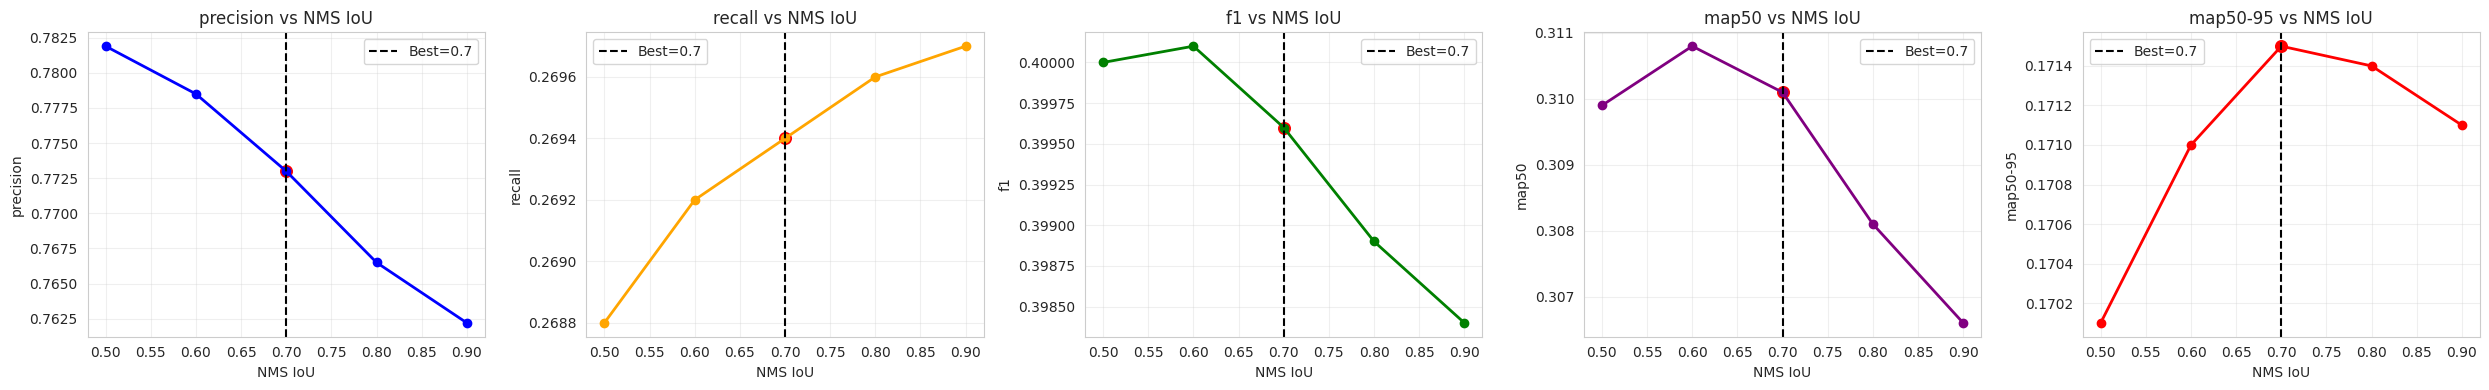

 nms_iou  precision  recall     f1  map50  map50-95  total_tp  total_fp  total_fn
     0.5     0.7819  0.2688 0.4000 0.3099    0.1701     51307     14310    139581
     0.6     0.7785  0.2692 0.4001 0.3108    0.1710     51395     14619    139493
     0.7     0.7730  0.2694 0.3996 0.3101    0.1715     51432     15100    139456
     0.8     0.7665  0.2696 0.3989 0.3081    0.1714     51461     15676    139427
     0.9     0.7622  0.2697 0.3984 0.3066    0.1711     51475     16063    139413


In [104]:
df_nms, best_nms = tune_nms_iou(
    pred_yoloe=pred_yoloe,
    class_concepts=CLASS_CONCEPTS,
    gt_dict=GT,
    target_classes=TARGET_CLASSES,
    best_alpha=best_alpha,
    best_low_conf_thr=best_thr,
    nms_iou_list=[0.50,0.60,0.70,0.80,0.90],
    eval_conf_thr=EVAL_CONF_THR,
    eval_iou_thr=IOU_THR,
    rerank_fn=clip_kg_optimize
)

print(df_nms.to_string(index=False))